In [1]:
import pandas as pd
from pathlib import Path
df=pd.read_csv(Path('car_insurance.csv'))


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   10000 non-null  int64  
 1   age                  10000 non-null  int64  
 2   gender               10000 non-null  int64  
 3   driving_experience   10000 non-null  object 
 4   education            10000 non-null  object 
 5   income               10000 non-null  object 
 6   credit_score         9018 non-null   float64
 7   vehicle_ownership    10000 non-null  float64
 8   vehicle_year         10000 non-null  object 
 9   married              10000 non-null  float64
 10  children             10000 non-null  float64
 11  postal_code          10000 non-null  int64  
 12  annual_mileage       9043 non-null   float64
 13  vehicle_type         10000 non-null  object 
 14  speeding_violations  10000 non-null  int64  
 15  duis                 10000 non-null  

In [3]:
df.isnull().sum()

id                       0
age                      0
gender                   0
driving_experience       0
education                0
income                   0
credit_score           982
vehicle_ownership        0
vehicle_year             0
married                  0
children                 0
postal_code              0
annual_mileage         957
vehicle_type             0
speeding_violations      0
duis                     0
past_accidents           0
outcome                  0
dtype: int64

In [4]:
df.select_dtypes(include=['object','category']).apply(pd.Series.value_counts)

,driving_experience,education,income,vehicle_year,vehicle_type
0-9y,3530.0,NaN,NaN,NaN,NaN
10-19y,3299.0,NaN,NaN,NaN,NaN
20-29y,2119.0,NaN,NaN,NaN,NaN
30y+,1052.0,NaN,NaN,NaN,NaN
after 2015,NaN,NaN,NaN,3033.0,NaN
before 2015,NaN,NaN,NaN,6967.0,NaN
high school,NaN,4157.0,NaN,NaN,NaN
middle class,NaN,NaN,2138.0,NaN,NaN
none,NaN,1915.0,NaN,NaN,NaN
poverty,NaN,NaN,1814.0,NaN,NaN


In [5]:
df['credit_score'].describe()

count    9018.000000
mean        0.515813
std         0.137688
min         0.053358
25%         0.417191
50%         0.525033
75%         0.618312
max         0.960819
Name: credit_score, dtype: float64

<Axes: xlabel='credit_score', ylabel='Count'>

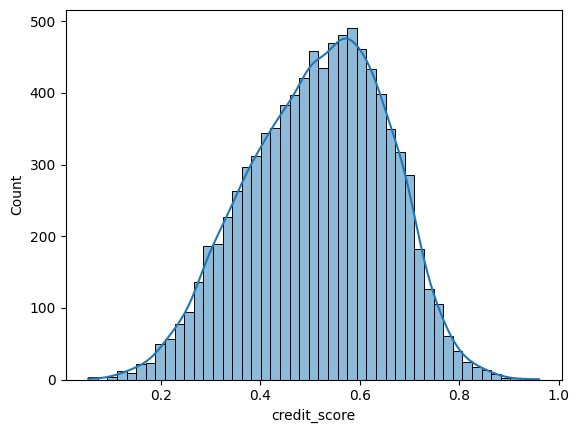

In [6]:
import seaborn as sns
sns.histplot(df['credit_score'], kde=True)

<Axes: xlabel='credit_score'>

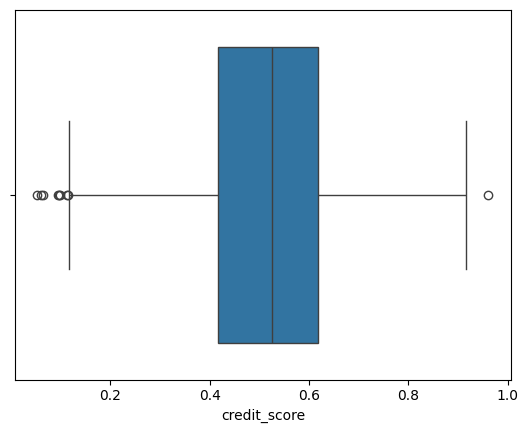

In [7]:
import seaborn as sns
sns.boxplot(x=df['credit_score'])

In [8]:
df['credit_score']=df['credit_score'].fillna(df['credit_score'].mean())
df['annual_mileage']=df['annual_mileage'].fillna(df['annual_mileage'].mean())

In [9]:
df.head()

,id,age,gender,driving_experience,education,income,credit_score,vehicle_ownership,vehicle_year,married,children,postal_code,annual_mileage,vehicle_type,speeding_violations,duis,past_accidents,outcome
0,569520,3,0,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,0,1,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,0,0,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,0,1,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,1,1,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


In [10]:
import pandas as pd

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [11]:
df['driving_experience'].value_counts()

driving_experience
0-9y      3530
10-19y    3299
20-29y    2119
30y+      1052
Name: count, dtype: int64

In [12]:
df["driving_experience"] = df["driving_experience"].map({
    "0-9y": 0,
    "10-19y": 1,
    "20-29y": 2,
    "30y+": 3
})

In [13]:
df['education'].value_counts()

education
high school    4157
university     3928
none           1915
Name: count, dtype: int64

In [14]:
df['education']=df['education'].map({
    'high school':2,
    'university':1,
    'none':02

})

SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (2927206003.py, line 4)

In [ ]:
df['income'].value_counts()

income
upper class      4336
middle class     2138
poverty          1814
working class    1712
Name: count, dtype: int64

In [ ]:
df['income']=df['income'].map({
    'upper class':3,
'middle class':2,
'poverty' :0,
'working class':1})

In [ ]:
df['vehicle_type'].value_counts()

vehicle_type
sedan         9523
sports car     477
Name: count, dtype: int64

In [ ]:
df['vehicle_year'].value_counts()

vehicle_year
before 2015    6967
after 2015     3033
Name: count, dtype: int64

In [ ]:
df['vehicle_year']=df['vehicle_year'].map({'before 2015':0,'after 2015':1
                                           })

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['vehicle_type']
numeric_cols = ['credit_score', 'annual_mileage']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

In [ ]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(['outcome','postal_code'], axis=1)
y = df['outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [ ]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [ ]:
y_pred = pipeline.predict(X_test)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.7126666666666667
Precision: 0.5813449023861171
Recall: 0.28601921024546423
F1-score: 0.3834048640915594
[[1870  193]
 [ 669  268]]
              precision    recall  f1-score   support

         0.0       0.74      0.91      0.81      2063
         1.0       0.58      0.29      0.38       937

    accuracy                           0.71      3000
   macro avg       0.66      0.60      0.60      3000
weighted avg       0.69      0.71      0.68      3000



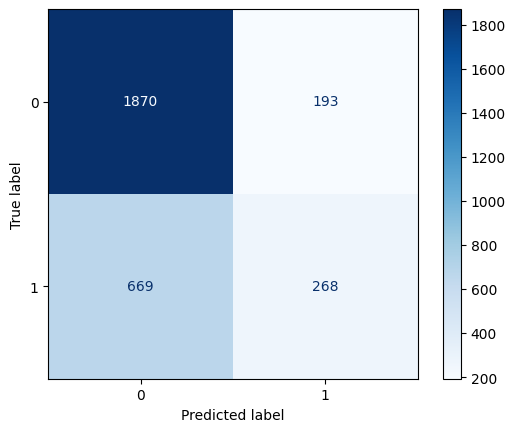

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.show()

In [ ]:
df['outcome'].value_counts(normalize=True)

outcome
0.0    0.6867
1.0    0.3133
Name: proportion, dtype: float64